In [1]:
import pickle
import matplotlib.pyplot as plt

In [2]:
ROOT_DIR = "/scratch4/workspace/ppruthi_umass_edu-CG/task_based_compositional_generalization"
import sys
sys.path.append("/scratch4/workspace/ppruthi_umass_edu-CG/task_based_compositional_generalization/src")


# Continuous coverage with varying KL divergence

In [37]:
import os
import datetime
seeds = [0, 10, 20, 30, 40]
pos_list = ["abs", "rel_global"]
strategies = ["continuouspaircoverage_6_0.0", "continuouspaircoverage_6_0.1", "continuouspaircoverage_6_0.2", "continuouspaircoverage_6_0.3", "continuouspaircoverage_6_0.4", "continuouspaircoverage_6_0.5", "continuouspaircoverage_6_0.6", "continuouspaircoverage_6_0.7", "continuouspaircoverage_6_0.8", "continuouspaircoverage_6_0.9", "continuouspaircoverage_6_1.0"]

count = 0
results = {}
for function_type in ["uniform", "diverse"]:
    results[function_type] = {}
    for mode in ["step_by_step", "direct"]:
        results[function_type][mode] = {}
        for pos in pos_list:
            results[function_type][mode][pos] = {}
            for strategy in strategies:
                results[function_type][mode][pos][strategy] = []
                for seed in seeds:
                    path = f"{ROOT_DIR}/models/eval/{function_type}/fixed/nalph_26_seqlen_6_fnlen_6_taskmaxlen_6/{mode}"
                    train_strategy_name = f"train_{strategy}"
                    eval_strategy_name = f"eval_{strategy}"
                    results_path = f"{path}/{train_strategy_name}/{eval_strategy_name}/{pos}/nh6_nl3/seed_{seed}/accs.pkl"

                
                    if function_type == "uniform" and mode == "direct":
                        results[function_type][mode][pos][strategy].append(0)
                    else:
                        if os.path.exists(results_path):
                            metrics = pickle.load(open(results_path, 'rb'))
                            results[function_type][mode][pos][strategy].append(metrics["test"].sharp_accuracy)
                        else:
                            count += 1

                    
            
print(count)
            # else:
            #     results[pos][strategy].append(0)

            
                
                
            # else:
            #     train_strategy_name = f"train_coverage_{strategy}"
            #     eval_strategy_name = f"eval_coverage_{strategy}"
            #     results_path = f"{path}/{train_strategy_name}/{eval_strategy_name}/{pos}/nh6_nl3/seed_{seed}/accs.pkl"
            #     metrics = pickle.load(open(results_path, 'rb'))
            #     results[pos][strategy].append(metrics["test"].sharp_accuracy)


0


step_by_step abs
step_by_step rel_global
direct abs
direct rel_global
{'direct_fixed': {'abs': 'tab:blue', 'rel_global': 'tab:red'}, 'step_by_step_fixed': {'abs': 'tab:green', 'rel_global': 'tab:orange'}}
step_by_step abs
tab:green
step_by_step rel_global
tab:orange
direct abs
tab:blue
direct rel_global
tab:red


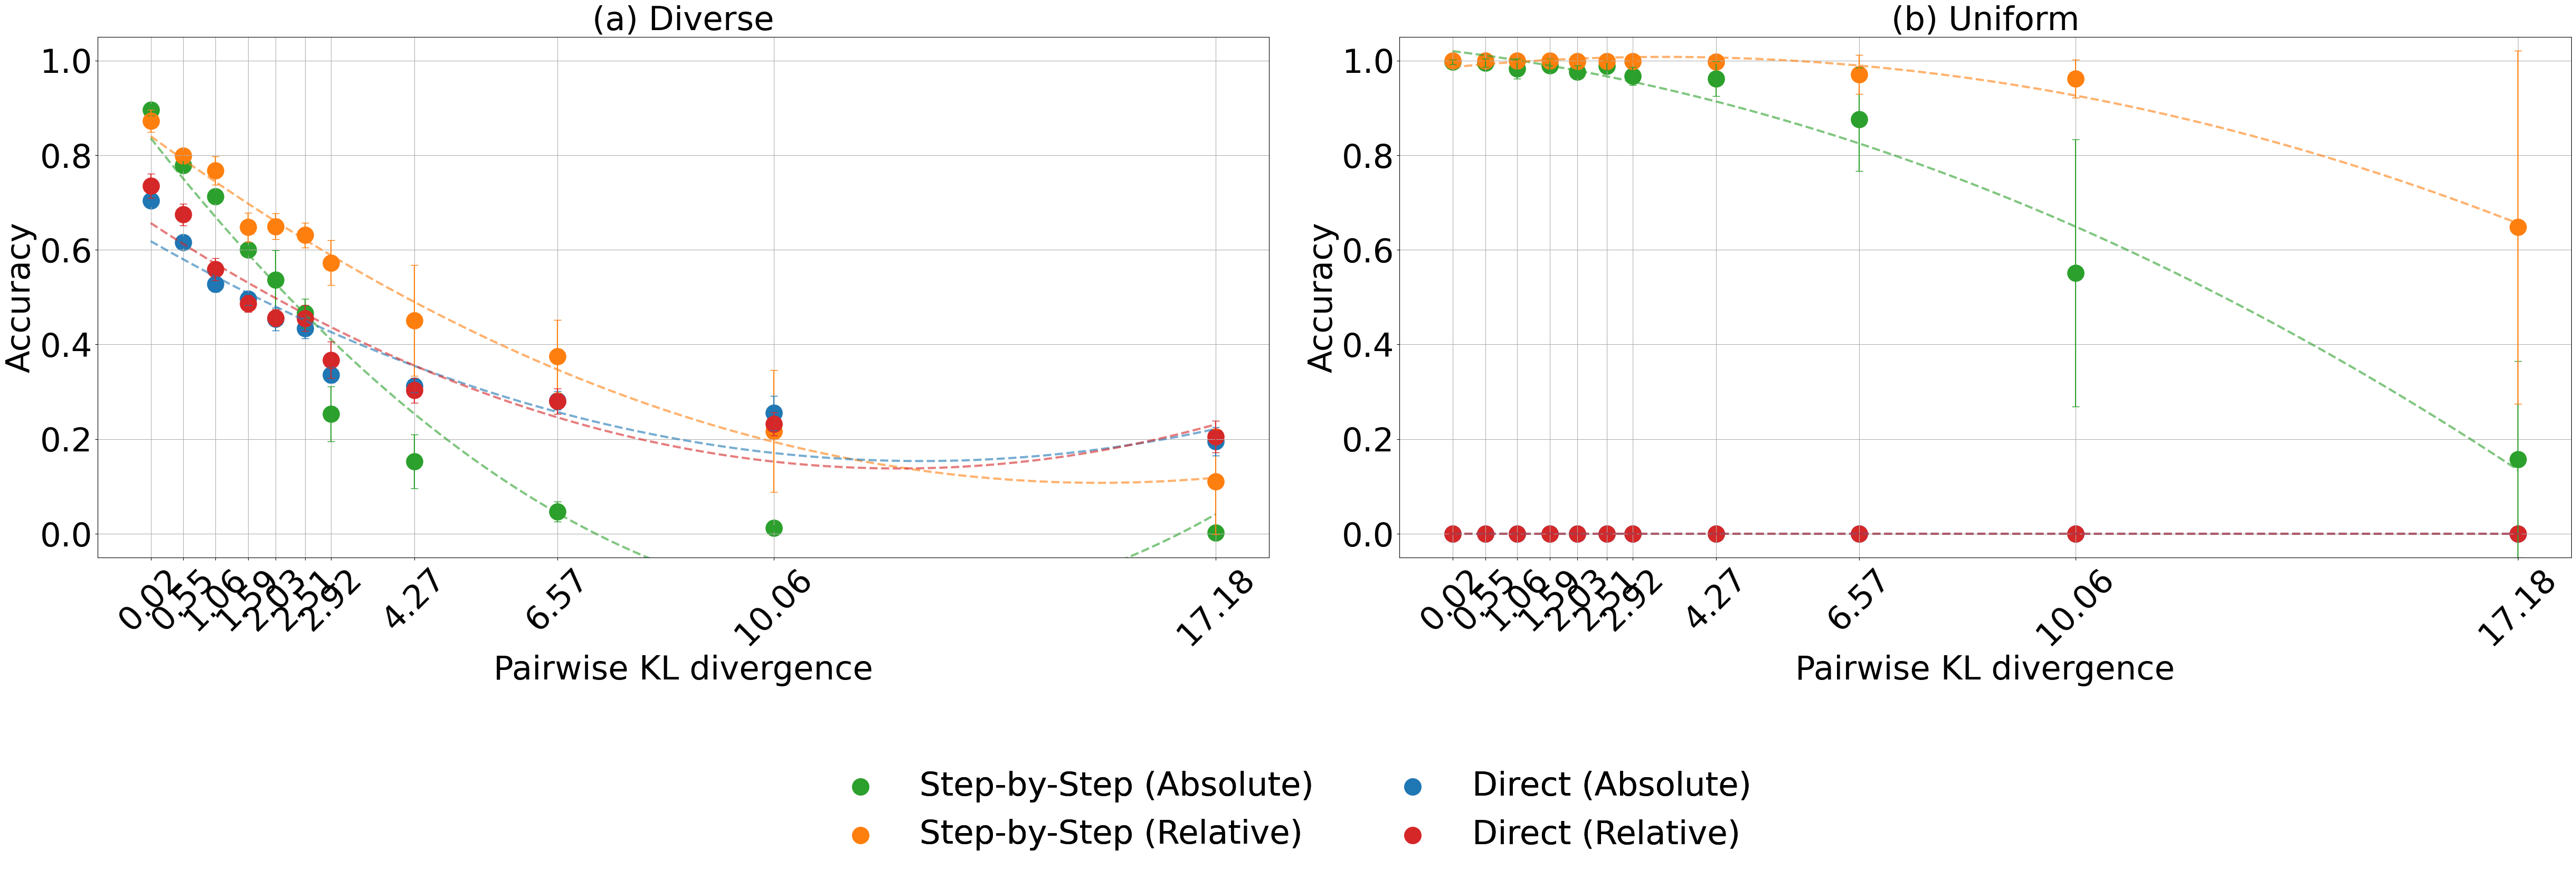

In [43]:
# plot line plot for with and without identity results side by side four plots with legend below 
from matplotlib import pyplot as plt
import numpy as np

font_size = 45
plt.rcParams.update({'font.size': font_size})
plt.rcParams.update({'legend.fontsize': font_size})
plt.rcParams.update({'axes.labelsize': font_size})
plt.rcParams.update({'axes.titlesize': font_size})
pos_kl_values = [0.024, 0.55, 1.063, 1.591, 2.034, 2.506, 2.925, 4.268, 6.573, 10.057, 17.179]
function_types = ["uniform"]

pos_types = ["abs", "rel_global"]
length = "fixed"

fig, axs = plt.subplots(1, 2, figsize=(50, 15))
# plot line plot for with and without identity results side by side four plots with legend below 
function_types = ["uniform", "diverse"]
modes = ["step_by_step", "direct"]
pos_types = ["abs", "rel_global"]
length = "fixed"
# have four subfigures with two plots each
colors = {
        "direct_fixed": {"abs": "tab:blue", "rel_global": "tab:red"},
        "step_by_step_fixed": {"abs": "tab:green", "rel_global": "tab:orange"},
    }

for j, mode in enumerate(modes):
    for k, pos in enumerate(pos_types):
        print(mode, pos)
        color = colors[mode + "_" + length][pos]
        
        pos_label = "Relative" if pos == "rel_global" else "Absolute"
        mode_label = "Direct" if mode == "direct" else "Step-by-Step"
        x_values = []
        y_values = []
        y_std = []
        
        for strategy_index, strategy in enumerate(strategies):
            
            
            if pos == "abs":
                x_values.append(pos_kl_values[strategy_index])
            else:
                x_values.append(pos_kl_values[strategy_index])
            # x_values.append(strategy)
            y_values.append(np.mean(results["diverse"][mode][pos][strategy]))
            y_std.append(np.std(results["diverse"][mode][pos][strategy]))
        
        from scipy.interpolate import make_interp_spline
        # Scatter and error bars as before
        axs[0].scatter(x_values, y_values, color=color, s=(font_size/2)**2, label=f"{mode_label} ({pos_label})")
        axs[0].errorbar(x_values, y_values, yerr=y_std, fmt="none", color=color, capsize=5)

        # Spline fit
        # Sort x and y for a reliable spline, and avoid duplicate x values (requirement for make_interp_spline)
        x_arr = np.array(x_values)
        y_arr = np.array(y_values)
        sort_indices = np.argsort(x_arr)
        x_sort = x_arr[sort_indices]
        y_sort = y_arr[sort_indices]

        # If there are duplicates in x_sort, average y_sort at those locations to avoid errors
        unique_x, unique_indices = np.unique(x_sort, return_index=True)
        if len(unique_x) != len(x_sort):
            # Average y at duplicate x positions
            from collections import defaultdict
            x_to_ys = defaultdict(list)
            for xx, yy in zip(x_sort, y_sort):
                x_to_ys[xx].append(yy)
            x_dedup = []
            y_dedup = []
            for xx in sorted(x_to_ys.keys()):
                x_dedup.append(xx)
                y_dedup.append(np.mean(x_to_ys[xx]))
            x_sort = np.array(x_dedup)
            y_sort = np.array(y_dedup)

        # Instead of a spline that passes through all the points, use a simple linear fit (trend line)
        if len(x_sort) >= 2:
            fit = np.polyfit(x_sort, y_sort, 2)
            fit_fn = np.poly1d(fit)
            x_fit = np.linspace(np.min(x_sort), np.max(x_sort), 300)
            y_fit = fit_fn(x_fit)
            axs[0].plot(x_fit, y_fit, color=color, linestyle="--", linewidth=3, alpha=0.6)
        
        axs[0].set_title(f"(a) Diverse", fontsize=font_size)

print(colors)
for j, mode in enumerate(modes):
    for k, pos in enumerate(pos_types):
        print(mode, pos)
        color = colors[mode + "_" + length][pos]
        print(color)
        pos_label = "Relative" if pos == "rel_global" else "Absolute"
        mode_label = "Direct" if mode == "direct" else "Step-by-Step"
        x_values = []
        y_values = []
        y_std = []
        
        for strategy_index, strategy in enumerate(strategies):
            
            mean = np.mean(results["uniform"][mode][pos][strategy])
            # if mean < 0.9:
            if pos == "abs":
                x_values.append(pos_kl_values[strategy_index])
            else:
                x_values.append(pos_kl_values[strategy_index])
            # x_values.append(strategy)
            y_values.append(np.mean(results["uniform"][mode][pos][strategy]))
            y_std.append(np.std(results["uniform"][mode][pos][strategy]))
        
        axs[1].scatter(x_values, y_values, color=color, s=(font_size/2)**2, label=f"{mode_label} ({pos_label})")
        axs[1].errorbar(x_values, y_values, yerr=y_std, fmt="none", color=color, capsize=5)
        
        # Spline fit only if more than 3 unique points
        x_sort = np.array(x_values)
        y_sort = np.array(y_values)
        # Handle duplicate x values by averaging their y's
        unique_x, unique_indices = np.unique(x_sort, return_index=True)
        if len(unique_x) != len(x_sort):
            from collections import defaultdict
            x_to_ys = defaultdict(list)
            for xx, yy in zip(x_sort, y_sort):
                x_to_ys[xx].append(yy)
            x_dedup = []
            y_dedup = []
            for xx in sorted(x_to_ys.keys()):
                x_dedup.append(xx)
                y_dedup.append(np.mean(x_to_ys[xx]))
            x_sort = np.array(x_dedup)
            y_sort = np.array(y_dedup)

        if len(x_sort) >= 2:
            fit = np.polyfit(x_sort, y_sort, 2)
            fit_fn = np.poly1d(fit)
            x_fit = np.linspace(np.min(x_sort), np.max(x_sort), 300)
            y_fit = fit_fn(x_fit)
            axs[1].plot(x_fit, y_fit, color=color, linestyle="--", linewidth=3, alpha=0.6)
        # Spline fit
        
        axs[1].set_title(f"(b) Uniform", fontsize=font_size)

    axs[0].set_ylim(-0.05, 1.05)
    axs[1].set_ylim(-0.05, 1.05)
    
    axs[0].set_xlabel("Pairwise KL divergence", fontsize=font_size)
    axs[1].set_xlabel("Pairwise KL divergence", fontsize=font_size)
    # have y-axis label as Accuracy
    axs[0].set_ylabel("Accuracy", fontsize=font_size)
    axs[1].set_ylabel("Accuracy", fontsize=font_size)
    # axs[2].set_ylabel("Accuracy", fontsize=font_size)
    # axs[3].set_ylabel("Accuracy", fontsize=font_size)

    # have legend below the four plots
    handles, labels = axs[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=2, fontsize=font_size, bbox_to_anchor=(0.5, -0.15), frameon=False)
    # have grid lines
    axs[0].grid(True)
    axs[1].grid(True)
    axs[0].set_xticks(pos_kl_values)
    axs[1].set_xticks(pos_kl_values)
    axs[0].tick_params(axis='x', rotation=45)
    axs[1].tick_params(axis='x', rotation=45)
    
    # annotate number of points in the plot for uniform and abs strategy per point

    
# Save figure with legend below the plots, ensuring legend is included in the saved file
plt.tight_layout(rect=[0, 0.05, 1, 1])  # leave space at bottom for legend
plt.savefig("Mod_pair_coverage_with_diversity.pdf", dpi=300, bbox_inches='tight')







# Control baseline for diversity

In [45]:
import os
import datetime
seeds = [0, 10, 20, 30, 40]
pos_list = ["abs", "rel_global"]
strategies = ["systematiccontinuouscoverage_6_0.0", "systematiccontinuouscoverage_6_0.1", "systematiccontinuouscoverage_6_0.2", "systematiccontinuouscoverage_6_0.3", "systematiccontinuouscoverage_6_0.4", "systematiccontinuouscoverage_6_0.5", "systematiccontinuouscoverage_6_0.6", "systematiccontinuouscoverage_6_0.7", "randomcontinuouscoverage_6_0.0", "randomcontinuouscoverage_6_0.1", "randomcontinuouscoverage_6_0.2", "randomcontinuouscoverage_6_0.3", "randomcontinuouscoverage_6_0.4", "randomcontinuouscoverage_6_0.5", "randomcontinuouscoverage_6_0.6", "randomcontinuouscoverage_6_0.7"]

count = 0
results = {}
for function_type in ["uniform", "diverse"]:
    results[function_type] = {}
    for mode in ["step_by_step", "direct"]:
        results[function_type][mode] = {}
        for pos in pos_list:
            results[function_type][mode][pos] = {}
            for strategy in strategies:
                results[function_type][mode][pos][strategy] = []
                for seed in seeds:
                    path = f"{ROOT_DIR}/models/eval/{function_type}/fixed/nalph_26_seqlen_6_fnlen_6_taskmaxlen_6/{mode}"
                    train_strategy_name = f"train_{strategy}"
                    eval_strategy_name = f"eval_{strategy}"
                    results_path = f"{path}/{train_strategy_name}/{eval_strategy_name}/{pos}/nh6_nl3/seed_{seed}/accs.pkl"

                
                    if function_type == "uniform" and mode == "direct":
                        results[function_type][mode][pos][strategy].append(0)
                    else:
                        metrics = pickle.load(open(results_path, 'rb'))
                        results[function_type][mode][pos][strategy].append(metrics["test"].sharp_accuracy)

                    
            
print(count)
            # else:
            #     results[pos][strategy].append(0)

            
                
                
            # else:
            #     train_strategy_name = f"train_coverage_{strategy}"
            #     eval_strategy_name = f"eval_coverage_{strategy}"
            #     results_path = f"{path}/{train_strategy_name}/{eval_strategy_name}/{pos}/nh6_nl3/seed_{seed}/accs.pkl"
            #     metrics = pickle.load(open(results_path, 'rb'))
            #     results[pos][strategy].append(metrics["test"].sharp_accuracy)


0


step_by_step abs
step_by_step rel_global
direct abs
direct rel_global
{'direct_fixed': {'abs': 'tab:blue', 'rel_global': 'tab:red'}, 'step_by_step_fixed': {'abs': 'tab:green', 'rel_global': 'tab:orange'}}
step_by_step abs
tab:green
step_by_step rel_global
tab:orange
direct abs
tab:blue
direct rel_global
tab:red


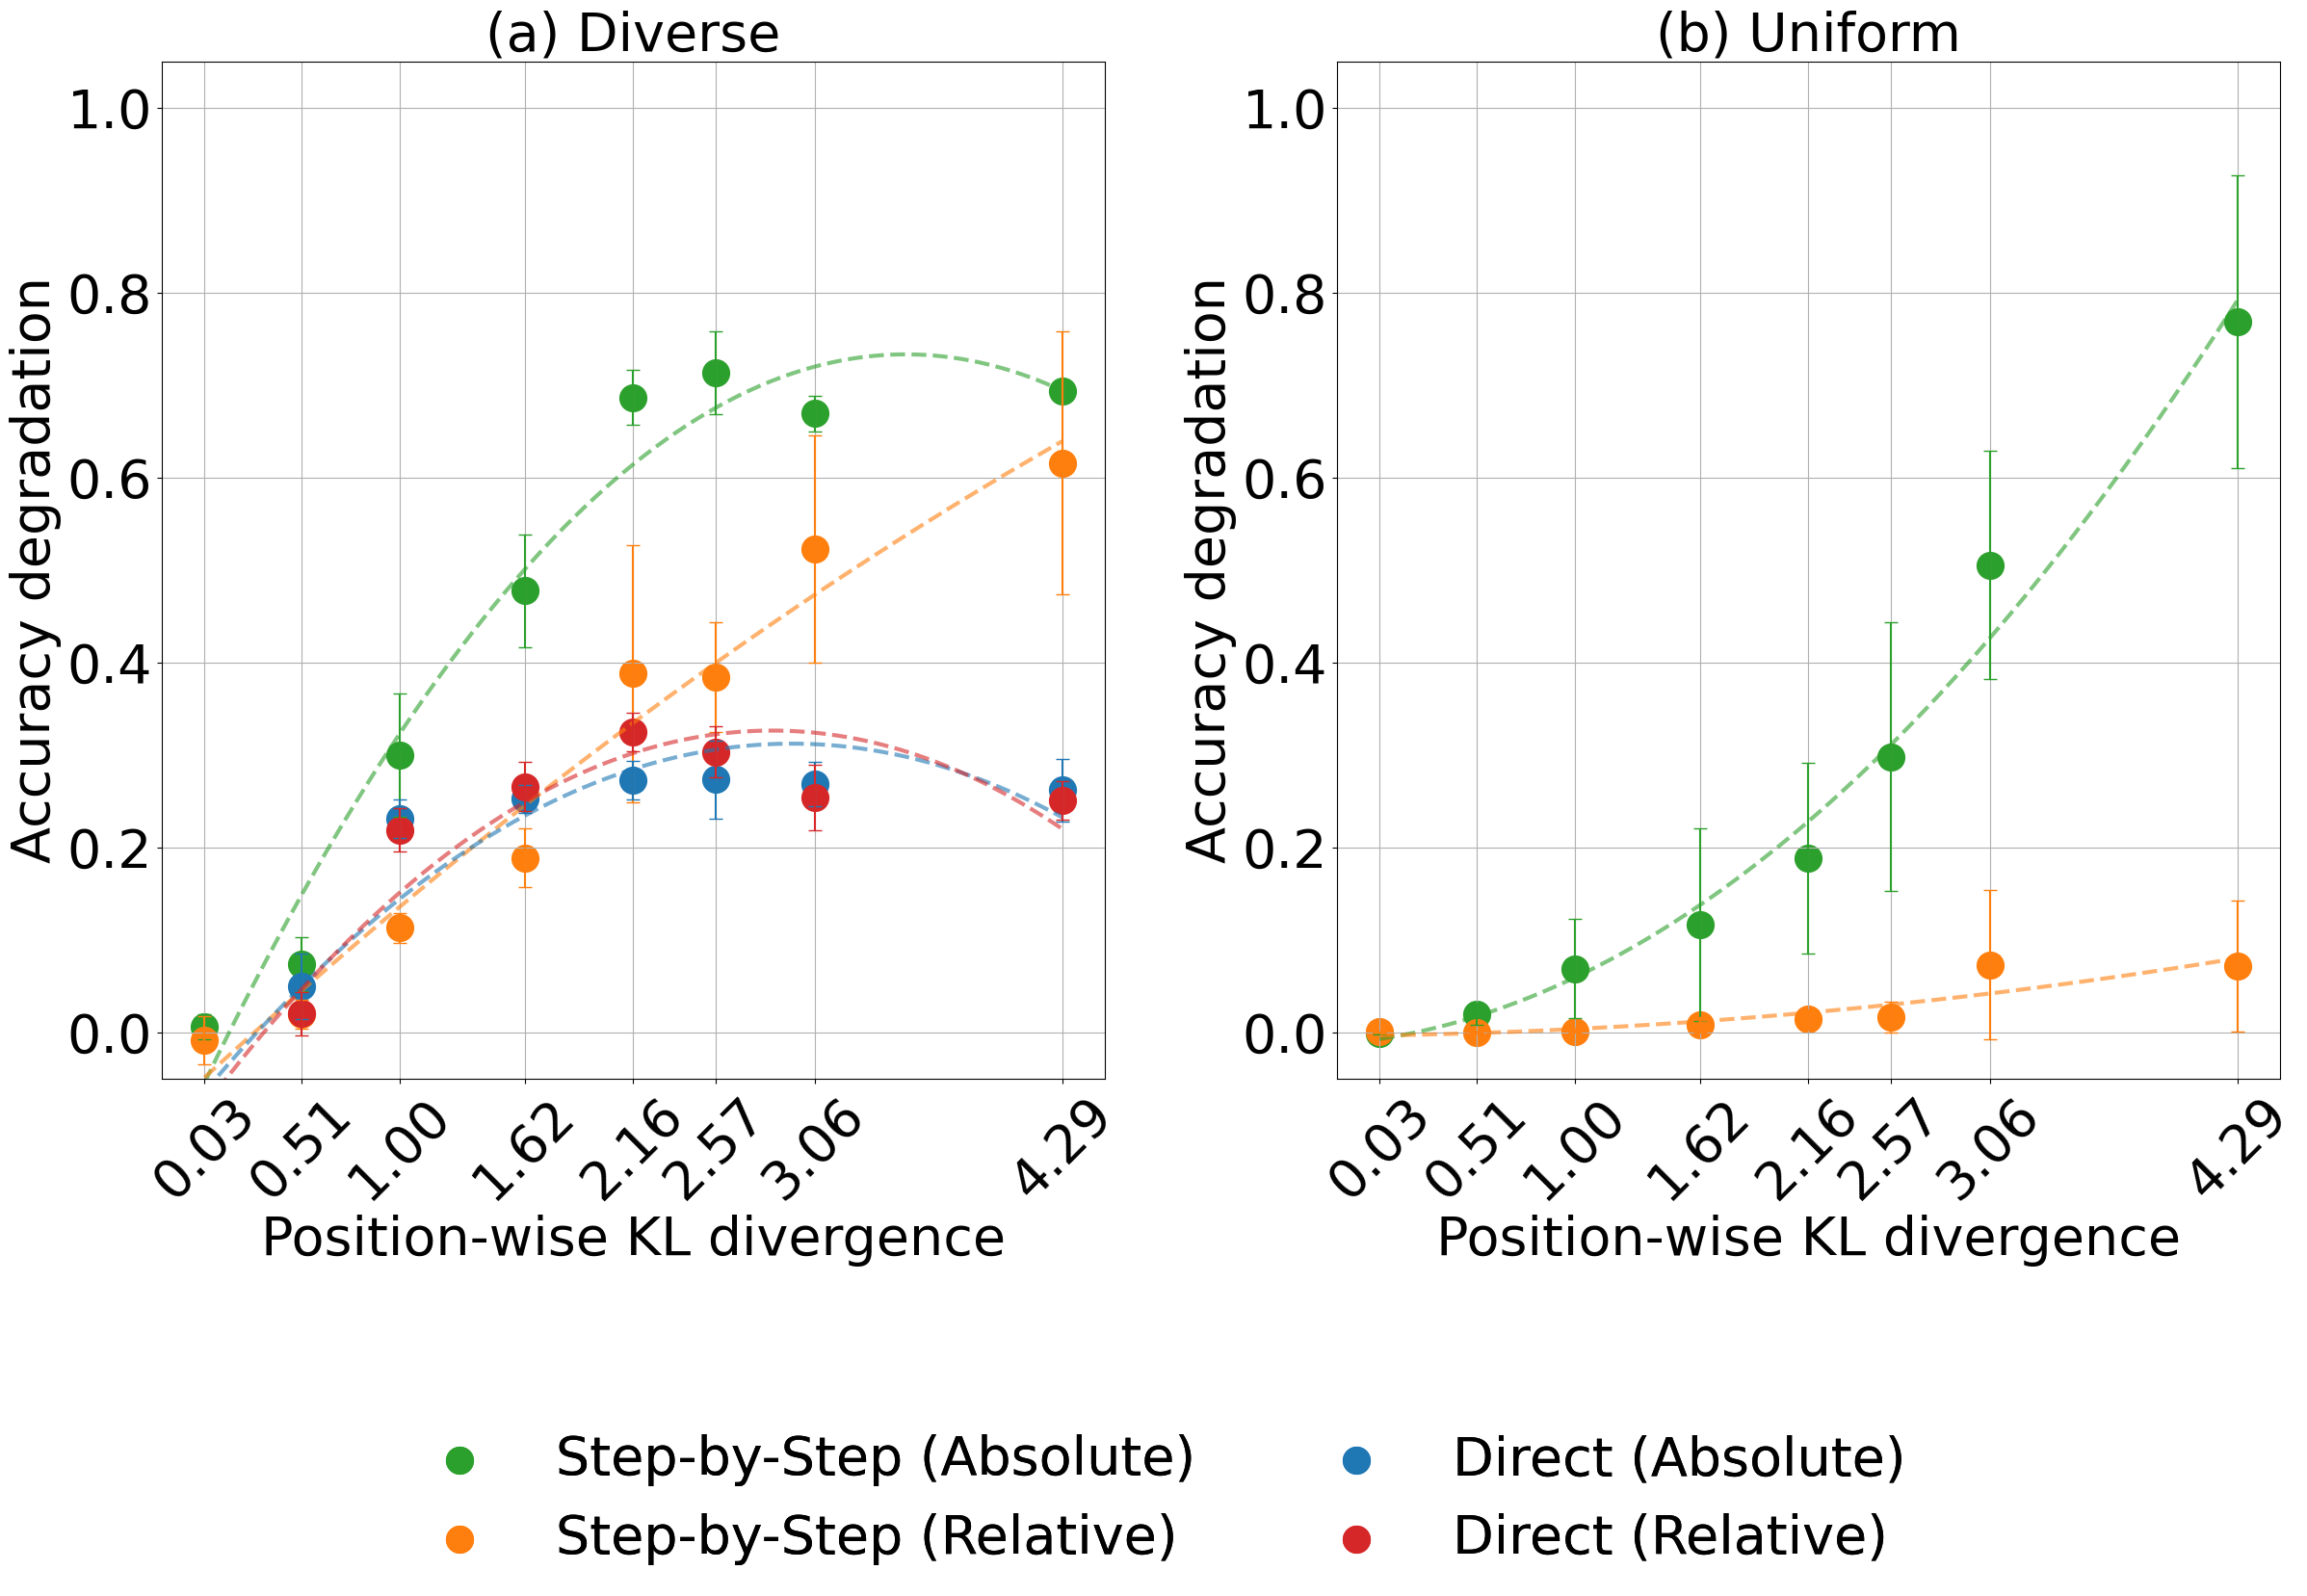

In [49]:
# plot line plot for with and without identity results side by side four plots with legend below 
from matplotlib import pyplot as plt
import numpy as np

font_size = 40
plt.rcParams.update({'font.size': font_size})
plt.rcParams.update({'legend.fontsize': font_size})
plt.rcParams.update({'axes.labelsize': font_size})
plt.rcParams.update({'axes.titlesize': font_size})
pos_kl_values = [0.03, 0.51, 1.00, 1.62, 2.16, 2.57, 3.06, 4.29]
function_types = ["uniform"]

pos_types = ["abs", "rel_global"]
length = "fixed"

fig, axs = plt.subplots(1, 2, figsize=(25, 15))
# plot line plot for with and without identity results side by side four plots with legend below 
function_types = ["uniform", "diverse"]
modes = ["step_by_step", "direct"]
pos_types = ["abs", "rel_global"]
length = "fixed"
# have four subfigures with two plots each
colors = {
        "direct_fixed": {"abs": "tab:blue", "rel_global": "tab:red"},
        "step_by_step_fixed": {"abs": "tab:green", "rel_global": "tab:orange"},
    }

for j, mode in enumerate(modes):
    for k, pos in enumerate(pos_types):
        print(mode, pos)
        color = colors[mode + "_" + length][pos]
        
        pos_label = "Relative" if pos == "rel_global" else "Absolute"
        mode_label = "Direct" if mode == "direct" else "Step-by-Step"
        x_values = []
        y_values = []
        y_std = []
        y_random_values = []
        y_random_std = []
        
        for strategy_index, strategy in enumerate(strategies):
            
            if "systematic" in strategy:
                x_values.append(pos_kl_values[strategy_index])
                
            if "systematic" in strategy:
                y_values.append(np.mean(results["diverse"][mode][pos][strategy]))
                y_std.append(np.std(results["diverse"][mode][pos][strategy]))
            else:
                y_random_values.append(np.mean(results["diverse"][mode][pos][strategy]))
                y_random_std.append(np.std(results["diverse"][mode][pos][strategy]))
        
        from scipy.interpolate import make_interp_spline
        # Scatter and error bars as before
        y_values = np.array(y_random_values) - np.array(y_values)
        
        axs[0].scatter(x_values, y_values, color=color, s=(font_size/2)**2, label=f"{mode_label} ({pos_label})", marker="o")
        # axs[0].scatter(x_values, y_random_values, color=color, s=(font_size/2)**2, marker="v")
        axs[0].errorbar(x_values, y_values, yerr=y_std, fmt="none", color=color, capsize=5)
        # axs[0].errorbar(x_values, y_random_values, yerr=y_random_std, fmt="none", color=color, capsize=5)

        # Spline fit
        # Sort x and y for a reliable spline, and avoid duplicate x values (requirement for make_interp_spline)
        x_arr = np.array(x_values)
        y_arr = np.array(y_values)
        sort_indices = np.argsort(x_arr)
        x_sort = x_arr[sort_indices]
        y_sort = y_arr[sort_indices]

        # If there are duplicates in x_sort, average y_sort at those locations to avoid errors
        unique_x, unique_indices = np.unique(x_sort, return_index=True)
        if len(unique_x) != len(x_sort):
            # Average y at duplicate x positions
            from collections import defaultdict
            x_to_ys = defaultdict(list)
            for xx, yy in zip(x_sort, y_sort):
                x_to_ys[xx].append(yy)
            x_dedup = []
            y_dedup = []
            for xx in sorted(x_to_ys.keys()):
                x_dedup.append(xx)
                y_dedup.append(np.mean(x_to_ys[xx]))
            x_sort = np.array(x_dedup)
            y_sort = np.array(y_dedup)

        # Instead of a spline that passes through all the points, use a simple linear fit (trend line)
        if len(x_sort) >= 2:
            fit = np.polyfit(x_sort, y_sort, 2)
            fit_fn = np.poly1d(fit)
            x_fit = np.linspace(np.min(x_sort), np.max(x_sort), 300)
            y_fit = fit_fn(x_fit)
            axs[0].plot(x_fit, y_fit, color=color, linestyle="--", linewidth=3, alpha=0.6)
        
        axs[0].set_title(f"(a) Diverse", fontsize=font_size)

print(colors)
for j, mode in enumerate(modes):
    for k, pos in enumerate(pos_types):
        print(mode, pos)
        color = colors[mode + "_" + length][pos]
        print(color)
        pos_label = "Relative" if pos == "rel_global" else "Absolute"
        mode_label = "Direct" if mode == "direct" else "Step-by-Step"
        x_values = []
        y_values = []
        y_std = []
        y_random_values = []
        y_random_std = []
        
        for strategy_index, strategy in enumerate(strategies):
            if mode == "direct":
                continue
            
            mean = np.mean(results["uniform"][mode][pos][strategy])
            # if mean < 0.9:
            if "systematic" in strategy:
                x_values.append(pos_kl_values[strategy_index])
            
            if "systematic" in strategy:
                y_values.append(np.mean(results["uniform"][mode][pos][strategy]))
                y_std.append(np.std(results["uniform"][mode][pos][strategy]))
            else:
                y_random_values.append(np.mean(results["uniform"][mode][pos][strategy]))
                y_random_std.append(np.std(results["uniform"][mode][pos][strategy]))
        
        y_values = np.array(y_random_values) - np.array(y_values)
        # print(y_values)
        axs[1].scatter(x_values, y_values, color=color, s=(font_size/2)**2, label=f"{mode_label} ({pos_label})")
        axs[1].errorbar(x_values, y_values, yerr=y_std, fmt="none", color=color, capsize=5)
        # axs[1].scatter(x_values, y_random_values, color=color, s=(font_size/2)**2, marker="v")
        # axs[1].errorbar(x_values, y_random_values, yerr=y_random_std, fmt="none", color=color, capsize=5)
        
        # Spline fit only if more than 3 unique points
        x_sort = np.array(x_values)
        y_sort = np.array(y_values)
        # Handle duplicate x values by averaging their y's
        unique_x, unique_indices = np.unique(x_sort, return_index=True)
        if len(unique_x) != len(x_sort):
            from collections import defaultdict
            x_to_ys = defaultdict(list)
            for xx, yy in zip(x_sort, y_sort):
                x_to_ys[xx].append(yy)
            x_dedup = []
            y_dedup = []
            for xx in sorted(x_to_ys.keys()):
                x_dedup.append(xx)
                y_dedup.append(np.mean(x_to_ys[xx]))
            x_sort = np.array(x_dedup)
            y_sort = np.array(y_dedup)

        if len(x_sort) >= 2:
            fit = np.polyfit(x_sort, y_sort, 2)
            fit_fn = np.poly1d(fit)
            x_fit = np.linspace(np.min(x_sort), np.max(x_sort), 300)
            y_fit = fit_fn(x_fit)
            axs[1].plot(x_fit, y_fit, color=color, linestyle="--", linewidth=3, alpha=0.6)
        # Spline fit
        
        axs[1].set_title(f"(b) Uniform", fontsize=font_size)

    axs[0].set_ylim(-0.05, 1.05)
    axs[1].set_ylim(-0.05, 1.05)
    
    axs[0].set_xlabel("Position-wise KL divergence", fontsize=font_size)
    axs[1].set_xlabel("Position-wise KL divergence", fontsize=font_size)
    # have y-axis label as Accuracy
    axs[0].set_ylabel("Accuracy degradation", fontsize=font_size)
    axs[1].set_ylabel("Accuracy degradation", fontsize=font_size)
    # axs[2].set_ylabel("Accuracy", fontsize=font_size)
    # axs[3].set_ylabel("Accuracy", fontsize=font_size)

    # have legend below the four plots
    handles, labels = axs[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=2, fontsize=font_size, bbox_to_anchor=(0.5, -0.15), frameon=False)
    # have grid lines
    axs[0].grid(True)
    axs[1].grid(True)
    # have x-ticks to be exactly the pos_kl_values with 1 decimal place
    
    axs[0].set_xticks(pos_kl_values)
    axs[1].set_xticks(pos_kl_values)
    axs[0].tick_params(axis='x', rotation=45)
    axs[1].tick_params(axis='x', rotation=45)
    
# Save figure with legend below the plots, ensuring legend is included in the saved file
plt.tight_layout(rect=[0, 0.05, 1, 1])  # leave space at bottom for legend
plt.savefig("mod_coverage_diversity_controlled_baseline.pdf", dpi=300, bbox_inches='tight')







step_by_step abs
step_by_step rel_global
direct abs
direct rel_global
{'direct_fixed': {'abs': 'tab:blue', 'rel_global': 'tab:red'}, 'step_by_step_fixed': {'abs': 'tab:green', 'rel_global': 'tab:orange'}}
step_by_step abs
tab:green
step_by_step rel_global
tab:orange
direct abs
tab:blue
direct rel_global
tab:red


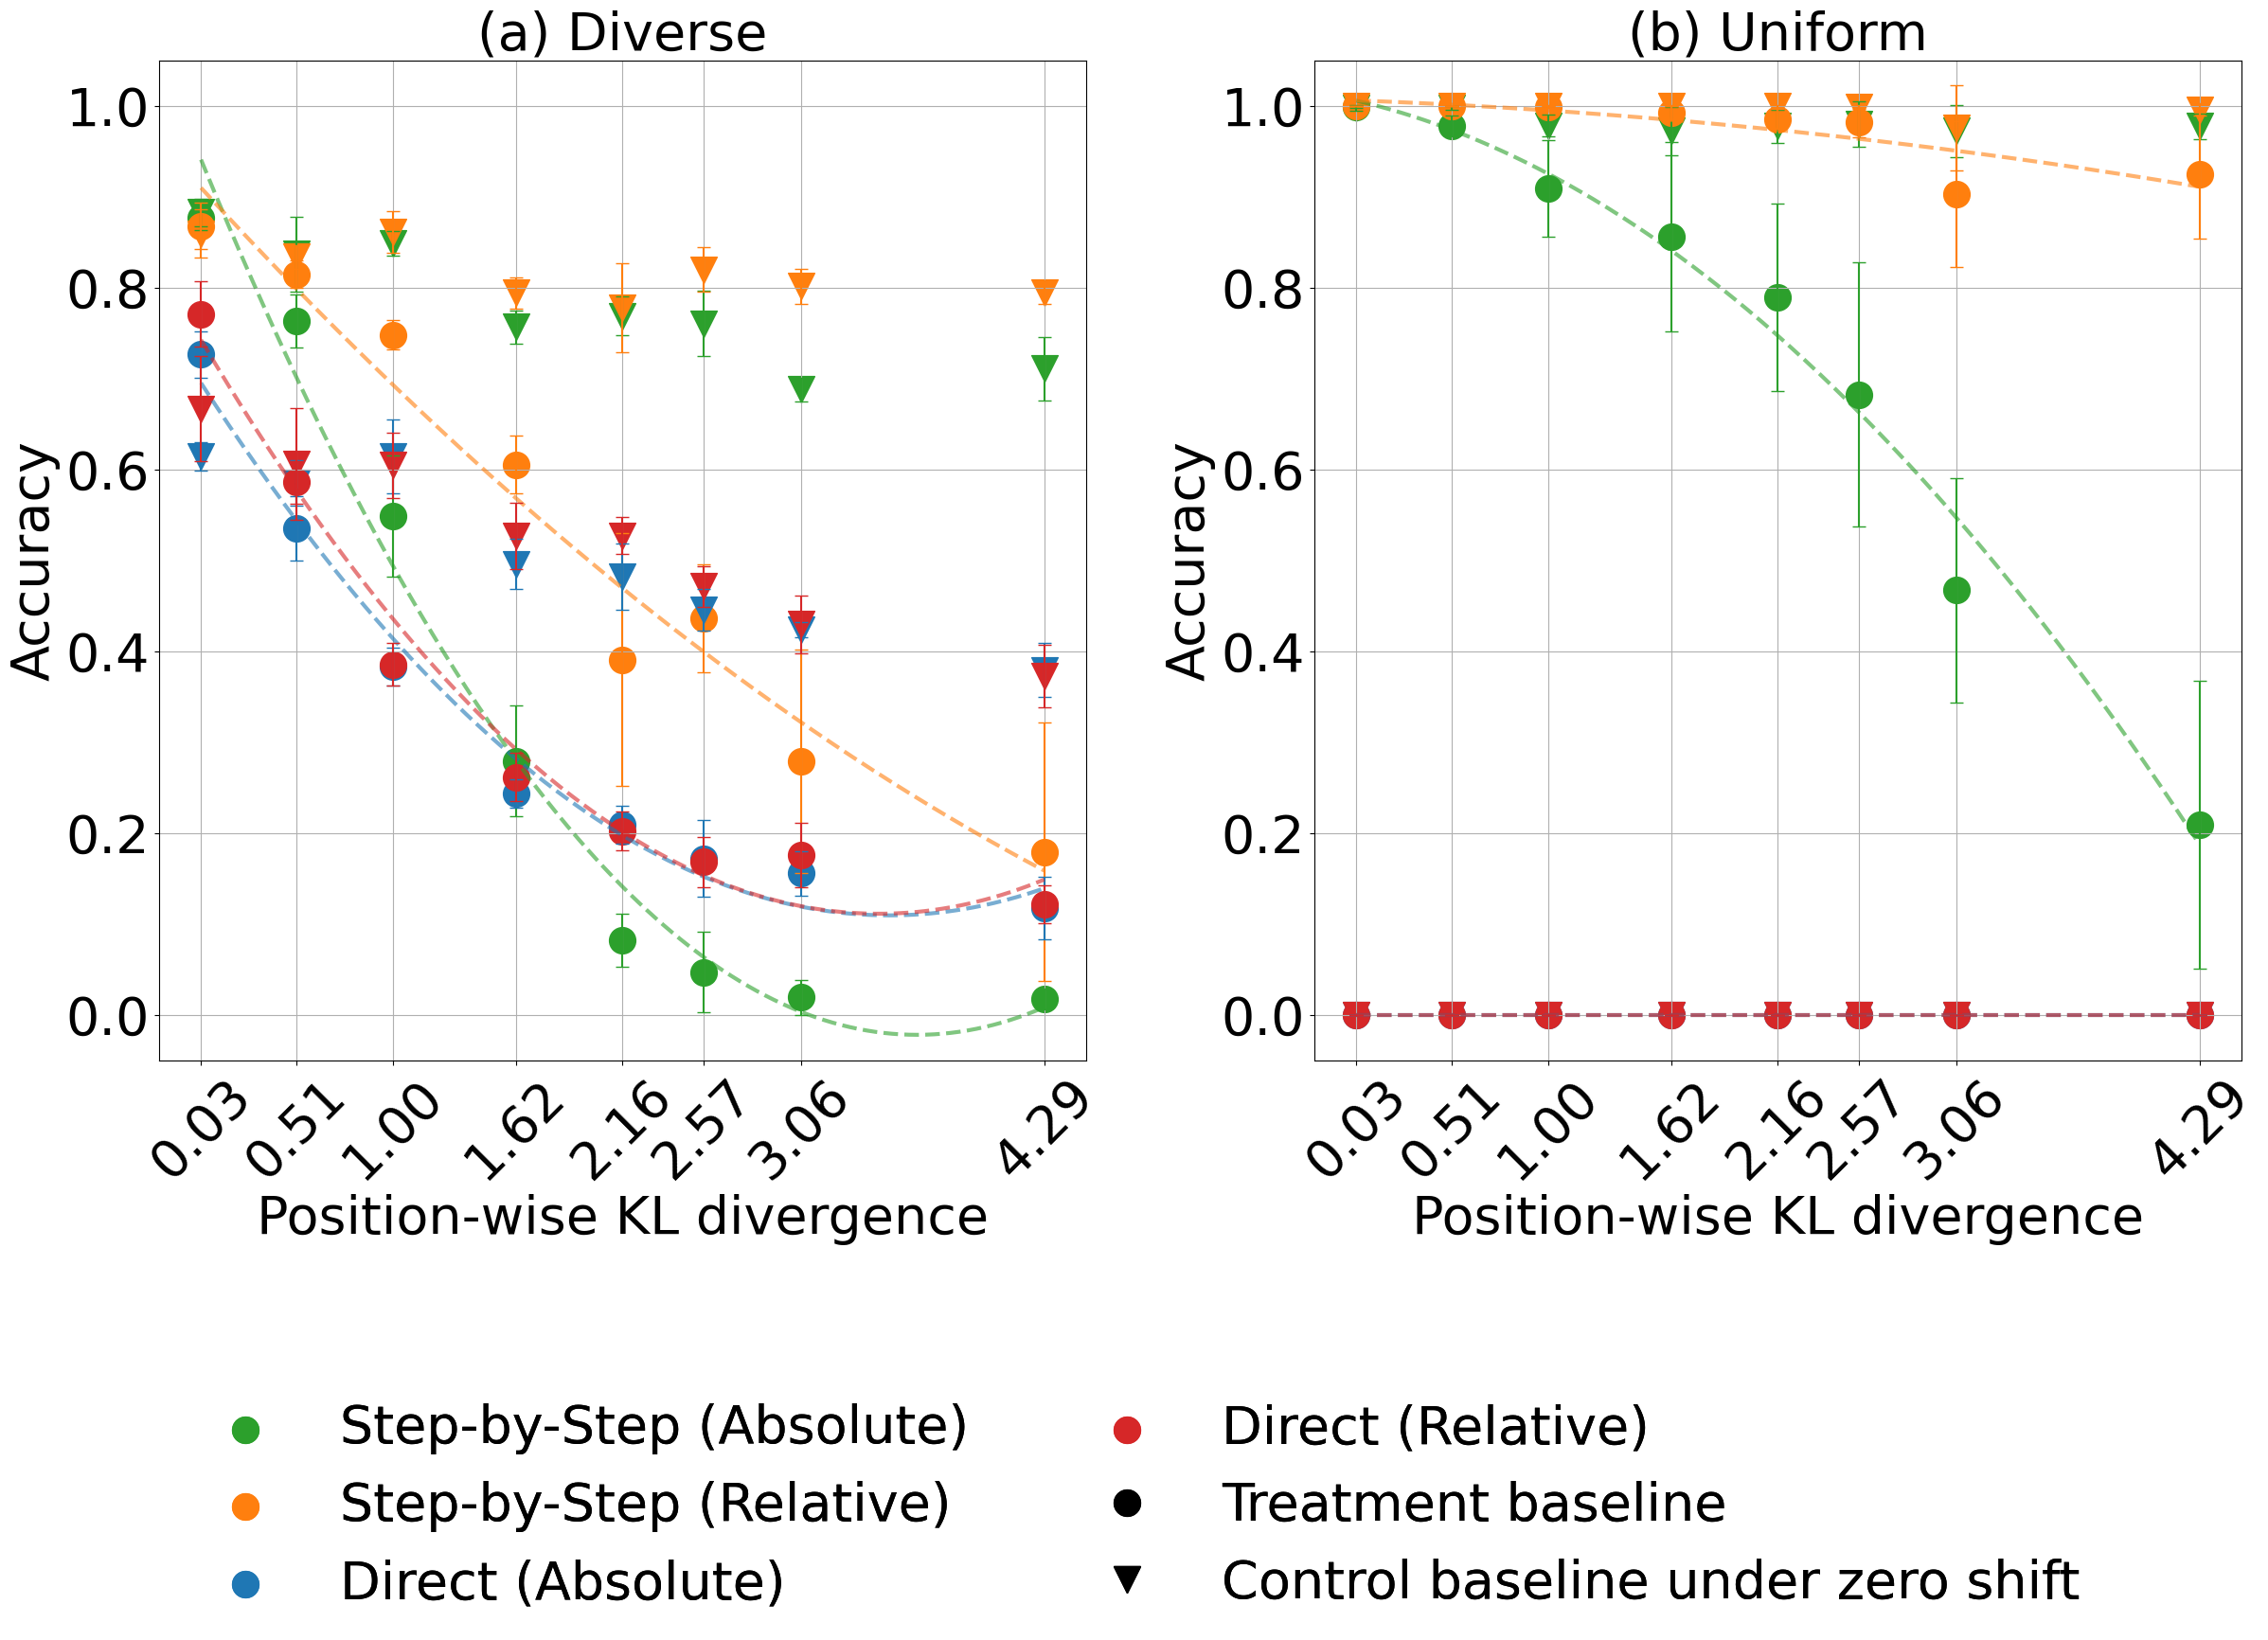

In [28]:
# plot line plot for with and without identity results side by side four plots with legend below 
from matplotlib import pyplot as plt
import numpy as np

font_size = 40
plt.rcParams.update({'font.size': font_size})
plt.rcParams.update({'legend.fontsize': font_size})
plt.rcParams.update({'axes.labelsize': font_size})
plt.rcParams.update({'axes.titlesize': font_size})
pos_kl_values = [0.03, 0.51, 1.00, 1.62, 2.16, 2.57, 3.06, 4.29]
function_types = ["uniform"]

pos_types = ["abs", "rel_global"]
length = "fixed"

fig, axs = plt.subplots(1, 2, figsize=(25, 15))
# plot line plot for with and without identity results side by side four plots with legend below 
function_types = ["uniform", "diverse"]
modes = ["step_by_step", "direct"]
pos_types = ["abs", "rel_global"]
length = "fixed"
# have four subfigures with two plots each
colors = {
        "direct_fixed": {"abs": "tab:blue", "rel_global": "tab:red"},
        "step_by_step_fixed": {"abs": "tab:green", "rel_global": "tab:orange"},
    }

for j, mode in enumerate(modes):
    for k, pos in enumerate(pos_types):
        print(mode, pos)
        color = colors[mode + "_" + length][pos]
        
        pos_label = "Relative" if pos == "rel_global" else "Absolute"
        mode_label = "Direct" if mode == "direct" else "Step-by-Step"
        x_values = []
        y_values = []
        y_std = []
        y_random_values = []
        y_random_std = []
        
        for strategy_index, strategy in enumerate(strategies):
            
            if "systematic" in strategy:
                x_values.append(pos_kl_values[strategy_index])
                
            if "systematic" in strategy:
                y_values.append(np.mean(results["diverse"][mode][pos][strategy]))
                y_std.append(np.std(results["diverse"][mode][pos][strategy]))
            else:
                y_random_values.append(np.mean(results["diverse"][mode][pos][strategy]))
                y_random_std.append(np.std(results["diverse"][mode][pos][strategy]))
        
        from scipy.interpolate import make_interp_spline
        # Scatter and error bars as before
        # y_values = np.array(y_random_values) - np.array(y_values)
        
        axs[0].scatter(x_values, y_values, color=color, s=(font_size/2)**2, label=f"{mode_label} ({pos_label})", marker="o")
        axs[0].scatter(x_values, y_random_values, color=color, s=(font_size/2)**2, marker="v")
        axs[0].errorbar(x_values, y_values, yerr=y_std, fmt="none", color=color, capsize=5)
        axs[0].errorbar(x_values, y_random_values, yerr=y_random_std, fmt="none", color=color, capsize=5)

        # Spline fit
        # Sort x and y for a reliable spline, and avoid duplicate x values (requirement for make_interp_spline)
        x_arr = np.array(x_values)
        y_arr = np.array(y_values)
        sort_indices = np.argsort(x_arr)
        x_sort = x_arr[sort_indices]
        y_sort = y_arr[sort_indices]

        # If there are duplicates in x_sort, average y_sort at those locations to avoid errors
        unique_x, unique_indices = np.unique(x_sort, return_index=True)
        if len(unique_x) != len(x_sort):
            # Average y at duplicate x positions
            from collections import defaultdict
            x_to_ys = defaultdict(list)
            for xx, yy in zip(x_sort, y_sort):
                x_to_ys[xx].append(yy)
            x_dedup = []
            y_dedup = []
            for xx in sorted(x_to_ys.keys()):
                x_dedup.append(xx)
                y_dedup.append(np.mean(x_to_ys[xx]))
            x_sort = np.array(x_dedup)
            y_sort = np.array(y_dedup)

        # Instead of a spline that passes through all the points, use a simple linear fit (trend line)
        if len(x_sort) >= 2:
            fit = np.polyfit(x_sort, y_sort, 2)
            fit_fn = np.poly1d(fit)
            x_fit = np.linspace(np.min(x_sort), np.max(x_sort), 300)
            y_fit = fit_fn(x_fit)
            axs[0].plot(x_fit, y_fit, color=color, linestyle="--", linewidth=3, alpha=0.6)
        
        axs[0].set_title(f"(a) Diverse", fontsize=font_size)

print(colors)
for j, mode in enumerate(modes):
    for k, pos in enumerate(pos_types):
        print(mode, pos)
        color = colors[mode + "_" + length][pos]
        print(color)
        pos_label = "Relative" if pos == "rel_global" else "Absolute"
        mode_label = "Direct" if mode == "direct" else "Step-by-Step"
        x_values = []
        y_values = []
        y_std = []
        y_random_values = []
        y_random_std = []
        
        for strategy_index, strategy in enumerate(strategies):
            
            mean = np.mean(results["uniform"][mode][pos][strategy])
            # if mean < 0.9:
            if "systematic" in strategy:
                x_values.append(pos_kl_values[strategy_index])
            
            if "systematic" in strategy:
                y_values.append(np.mean(results["uniform"][mode][pos][strategy]))
                y_std.append(np.std(results["uniform"][mode][pos][strategy]))
            else:
                y_random_values.append(np.mean(results["uniform"][mode][pos][strategy]))
                y_random_std.append(np.std(results["uniform"][mode][pos][strategy]))
        
        # y_values = np.array(y_random_values) - np.array(y_values)
        # print(y_values)
        axs[1].scatter(x_values, y_values, color=color, s=(font_size/2)**2, label=f"{mode_label} ({pos_label})")
        axs[1].errorbar(x_values, y_values, yerr=y_std, fmt="none", color=color, capsize=5)
        axs[1].scatter(x_values, y_random_values, color=color, s=(font_size/2)**2, marker="v")
        axs[1].errorbar(x_values, y_random_values, yerr=y_random_std, fmt="none", color=color, capsize=5)
        
        # Spline fit only if more than 3 unique points
        x_sort = np.array(x_values)
        y_sort = np.array(y_values)
        # Handle duplicate x values by averaging their y's
        unique_x, unique_indices = np.unique(x_sort, return_index=True)
        if len(unique_x) != len(x_sort):
            from collections import defaultdict
            x_to_ys = defaultdict(list)
            for xx, yy in zip(x_sort, y_sort):
                x_to_ys[xx].append(yy)
            x_dedup = []
            y_dedup = []
            for xx in sorted(x_to_ys.keys()):
                x_dedup.append(xx)
                y_dedup.append(np.mean(x_to_ys[xx]))
            x_sort = np.array(x_dedup)
            y_sort = np.array(y_dedup)

        if len(x_sort) >= 2:
            fit = np.polyfit(x_sort, y_sort, 2)
            fit_fn = np.poly1d(fit)
            x_fit = np.linspace(np.min(x_sort), np.max(x_sort), 300)
            y_fit = fit_fn(x_fit)
            axs[1].plot(x_fit, y_fit, color=color, linestyle="--", linewidth=3, alpha=0.6)
        # Spline fit
        
        axs[1].set_title(f"(b) Uniform", fontsize=font_size)

    axs[0].set_ylim(-0.05, 1.05)
    axs[1].set_ylim(-0.05, 1.05)
    
    axs[0].set_xlabel("Position-wise KL divergence", fontsize=font_size)
    axs[1].set_xlabel("Position-wise KL divergence", fontsize=font_size)
    # have y-axis label as Accuracy
    # axs[0].set_ylabel("Accuracy degradation", fontsize=font_size)
    # axs[1].set_ylabel("Accuracy degradation", fontsize=font_size)
    axs[0].set_ylabel("Accuracy", fontsize=font_size)
    axs[1].set_ylabel("Accuracy", fontsize=font_size)

    # have legend below the four plots
    handles, labels = axs[0].get_legend_handles_labels()
    # Add custom legend entries for the markers: 'o' is for model accuracy, 'v' is for uniform baseline
    import matplotlib.lines as mlines
    o_legend = mlines.Line2D([], [], color='black', marker='o', linestyle='None', markersize=font_size/2, label='Model')
    v_legend = mlines.Line2D([], [], color='black', marker='v', linestyle='None', markersize=font_size/2, label='Uniform baseline')
    # Compose complete legend including the marker explanations
    fig.legend(handles + [o_legend, v_legend], labels + ['Treatment baseline', 'Control baseline under zero shift'], 
               loc="lower center", ncol=2, fontsize=font_size, bbox_to_anchor=(0.5, -0.20), frameon=False)
    # have grid lines
    axs[0].grid(True)
    axs[1].grid(True)
    # have x-ticks to be exactly the pos_kl_values with 1 decimal place
    
    axs[0].set_xticks(pos_kl_values)
    axs[1].set_xticks(pos_kl_values)
    axs[0].tick_params(axis='x', rotation=45)
    axs[1].tick_params(axis='x', rotation=45)
    
# Save figure with legend below the plots, ensuring legend is included in the saved file
plt.tight_layout(rect=[0, 0.05, 1, 1])  # leave space at bottom for legend
plt.savefig("mod_coverage_diversity_reference_values.png", dpi=300, bbox_inches='tight')







# Simple plots

In [4]:
import os
import datetime
seeds = [0, 10, 20, 30, 40]
pos_list = ["abs", "rel_global"]
strategies = ["systematiccontinuouscoverage_6_0.0", "systematiccontinuouscoverage_6_0.1", "systematiccontinuouscoverage_6_0.2", "systematiccontinuouscoverage_6_0.3", "systematiccontinuouscoverage_6_0.4", "systematiccontinuouscoverage_6_0.5", "systematiccontinuouscoverage_6_0.6", "systematiccontinuouscoverage_6_0.7", "systematiccontinuouscoverage_6_0.8", "systematiccontinuouscoverage_6_0.9", "systematiccontinuouscoverage_6_1.0", "randomcontinuouscoverage_6_0.0", "randomcontinuouscoverage_6_0.1", "randomcontinuouscoverage_6_0.2", "randomcontinuouscoverage_6_0.3", "randomcontinuouscoverage_6_0.4", "randomcontinuouscoverage_6_0.5", "randomcontinuouscoverage_6_0.6", "randomcontinuouscoverage_6_0.7", "randomcontinuouscoverage_6_0.8", "randomcontinuouscoverage_6_0.9", "randomcontinuouscoverage_6_1.0"]


function_type = "uniform"
mode = "step_by_step"
count = 0
results = {}
for pos in pos_list:
    results[pos] = {}
    for strategy in strategies:
        results[pos][strategy] = []
        for seed in seeds:
            train_strategy_name = f"train_{strategy}"
            eval_strategy_name = f"eval_{strategy}"
            path = f"{ROOT_DIR}/models/eval/{function_type}/fixed/nalph_26_seqlen_6_fnlen_6_taskmaxlen_6/{mode}"
            results_path = f"{path}/{train_strategy_name}/{eval_strategy_name}/{pos}/nh6_nl3/seed_{seed}/accs.pkl"

           
            try:
                metrics = pickle.load(open(results_path, 'rb'))
                results[pos][strategy].append(metrics["test"].sharp_accuracy)
            except:
                print(f"Error loading results from {results_path}")
            
        
print(count)
            # else:
            #     results[pos][strategy].append(0)

            
                
                
            # else:
            #     train_strategy_name = f"train_coverage_{strategy}"
            #     eval_strategy_name = f"eval_coverage_{strategy}"
            #     results_path = f"{path}/{train_strategy_name}/{eval_strategy_name}/{pos}/nh6_nl3/seed_{seed}/accs.pkl"
            #     metrics = pickle.load(open(results_path, 'rb'))
            #     results[pos][strategy].append(metrics["test"].sharp_accuracy)


/work/pi_jensen_umass_edu/ppruthi_umass_edu/.conda/envs/CG/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


0


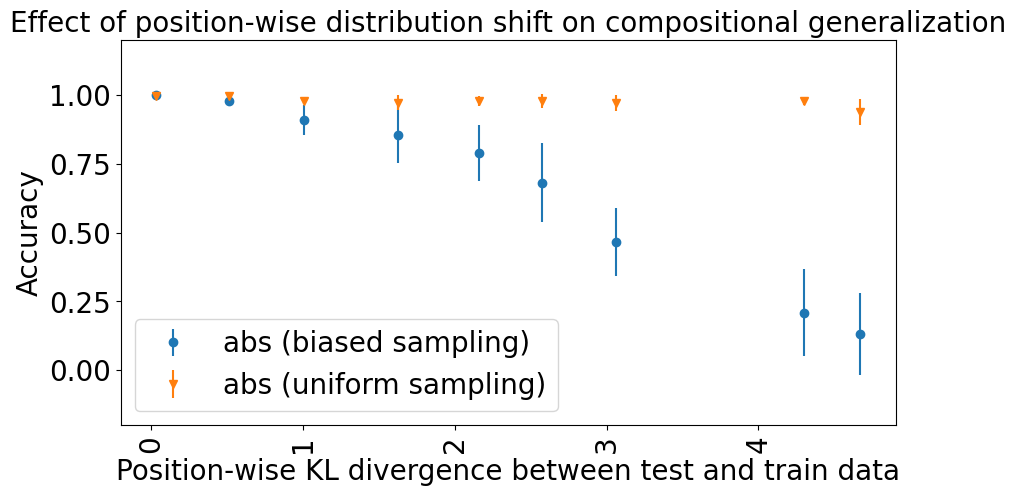

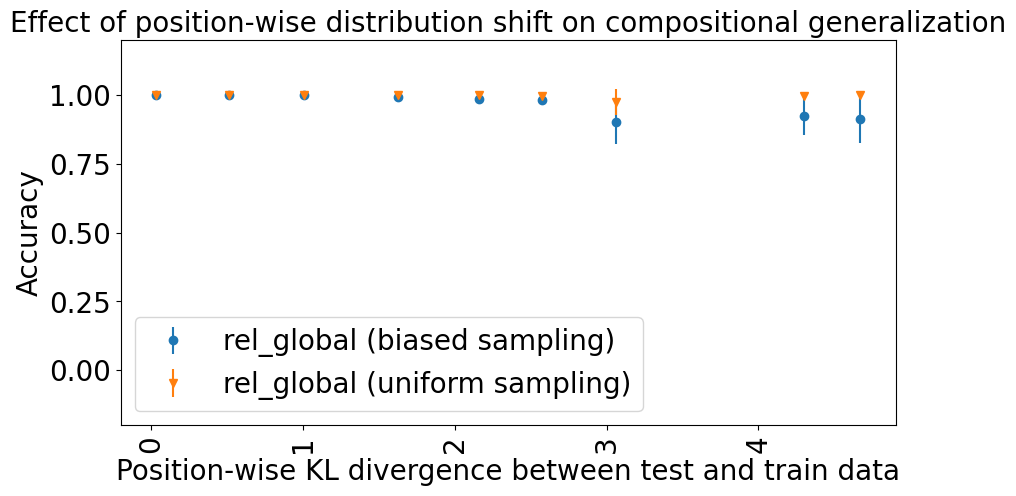

In [10]:
# find mean and std of results
font_size = 20
plt.rcParams.update({'font.size': font_size})
plt.rcParams.update({'legend.fontsize': font_size})
plt.rcParams.update({'axes.labelsize': font_size})
plt.rcParams.update({'axes.titlesize': font_size})

import numpy as np
# systematic 
pos_kl_values = [0.034, 0.515, 1.009, 1.625, 2.164, 2.575, 3.061, 4.299, 4.671, 8.681, 16.75 ]
# pair_kl_values = [0.012, 0.056, 0.085, 0.116, 0.179,0.181, 0.241, 0.233, 1.065, 1.173, 0.392]
# pos_kl_values = [0.108, 0.484, 0.547, 0.791, 1.768, 1.056, 2.799, 2.411, 3.567, 7.059]
# pair_kl_values = [0.024, 0.553, 1.063, 1.591, 2.034, 2.506, 2.925, 4.268, 6.573, 10.057, 17.179]
systematic_strategies = ["systematiccontinuouscoverage_6_0.0", "systematiccontinuouscoverage_6_0.1", "systematiccontinuouscoverage_6_0.2", "systematiccontinuouscoverage_6_0.3", "systematiccontinuouscoverage_6_0.4", "systematiccontinuouscoverage_6_0.5", "systematiccontinuouscoverage_6_0.6", "systematiccontinuouscoverage_6_0.7", "systematiccontinuouscoverage_6_0.8"]
random_strategies = ["randomcontinuouscoverage_6_0.0", "randomcontinuouscoverage_6_0.1", "randomcontinuouscoverage_6_0.2", "randomcontinuouscoverage_6_0.3", "randomcontinuouscoverage_6_0.4", "randomcontinuouscoverage_6_0.5", "randomcontinuouscoverage_6_0.6", "randomcontinuouscoverage_6_0.7", "randomcontinuouscoverage_6_0.8"]
for pos in pos_list:
    x_values = []
    y_values = []
    y_random_values = []
    y_std = []
    y_random_std = []
    plt.figure(figsize=(10, 5))
    for strategy_index, strategy in enumerate(systematic_strategies):
        
        mean = np.mean(results[pos][strategy])
        # if mean < 0.9:
        if pos == "abs":
            x_values.append(pos_kl_values[strategy_index])
        else:
            x_values.append(pos_kl_values[strategy_index])
        y_values.append(np.mean(results[pos][strategy]))
        y_random_values.append(np.mean(results[pos][random_strategies[strategy_index]]))
        y_std.append(np.std(results[pos][strategy]))
        y_random_std.append(np.std(results[pos][random_strategies[strategy_index]]))
        
        # print(pos, strategy,b
        # results[pos][strategy])
        # print(pos, strategy, np.mean(results[pos][strategy]), np.std(results[pos][strategy]))
        # plot error bar
        # have vertical line after each 6 strategies
    #     if int(strategy.split("_")[3]) == 0 or int(strategy.split("_")[3]) == 5:
    #         plt.axvline(x=strategy_index, color='black', linestyle='--')
    # # 
    plt.errorbar(x_values, y_values, yerr=y_std, fmt='o', label=f"{pos} (biased sampling)")
    plt.errorbar(x_values, y_random_values, yerr=y_random_std, fmt='v', label=f"{pos} (uniform sampling)")
    plt.title("Effect of position-wise distribution shift on compositional generalization")
    # x-axis labels at 45 degree angle
    plt.xticks(rotation=90)
    plt.xlabel("Position-wise KL divergence between test and train data")
    plt.ylabel("Accuracy")
    plt.ylim(-0.2, 1.2)
    plt.legend()
    plt.show()


# Position wise coverage violations

- Training data: 600 compositions
- Test data: 120 compositions

- Training compositions **never** observe a given module at a given position e.g., f1 never appears at position 0
- Test compositions **always** observe a given module at a given position, all compositions have f1 at position 0
- **Position Coverage Divergence (KL): 4.023595**
- Pairwise Adjacency Divergence (KL): 0.223144
- Combined Divergence (KL) (α=0.5): 2.12




In [76]:
import os
import datetime
seeds = [0, 10, 20, 30, 40]
pos_list = ["abs", "rel_global"]
strategies = ["coverage_6_0_0", "coverage_6_0_1", "coverage_6_0_2", "coverage_6_0_3", "coverage_6_0_4", "coverage_6_0_5", 
              "coverage_6_1_0", "coverage_6_1_1", "coverage_6_1_2", "coverage_6_1_3", "coverage_6_1_4", "coverage_6_1_5", 
              "coverage_6_2_0", "coverage_6_2_1", "coverage_6_2_2", "coverage_6_2_3", "coverage_6_2_4", "coverage_6_2_5", 
              "coverage_6_3_0", "coverage_6_3_1", "coverage_6_3_2", "coverage_6_3_3", "coverage_6_3_4", "coverage_6_3_5", 
              "coverage_6_4_0", "coverage_6_4_1", "coverage_6_4_2", "coverage_6_4_3", "coverage_6_4_4", "coverage_6_4_5", 
              "coverage_6_5_0", "coverage_6_5_1", "coverage_6_5_2", "coverage_6_5_3", "coverage_6_5_4", "coverage_6_5_5"]

count = 0
results = {}
for pos in pos_list:
    results[pos] = {}
    for strategy in strategies:
        results[pos][strategy] = []
        for seed in seeds:
            train_strategy_name = f"train_{strategy}"
            eval_strategy_name = f"eval_{strategy}"
            results_path = f"{path}/{train_strategy_name}/{eval_strategy_name}/{pos}/nh6_nl3/seed_{seed}/accs.pkl"

           
            
            metrics = pickle.load(open(results_path, 'rb'))
            results[pos][strategy].append(metrics["test"].sharp_accuracy)
            
        
print(count)
            # else:
            #     results[pos][strategy].append(0)

            
                
                
            # else:
            #     train_strategy_name = f"train_coverage_{strategy}"
            #     eval_strategy_name = f"eval_coverage_{strategy}"
            #     results_path = f"{path}/{train_strategy_name}/{eval_strategy_name}/{pos}/nh6_nl3/seed_{seed}/accs.pkl"
            #     metrics = pickle.load(open(results_path, 'rb'))
            #     results[pos][strategy].append(metrics["test"].sharp_accuracy)


0


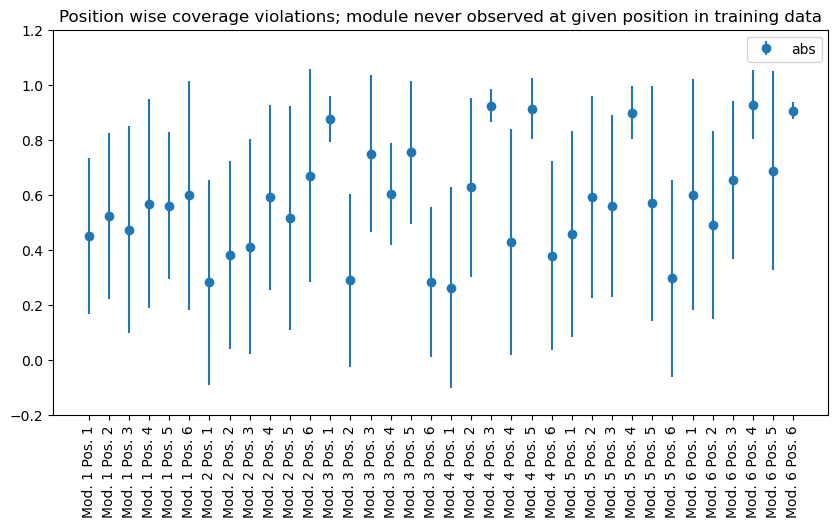

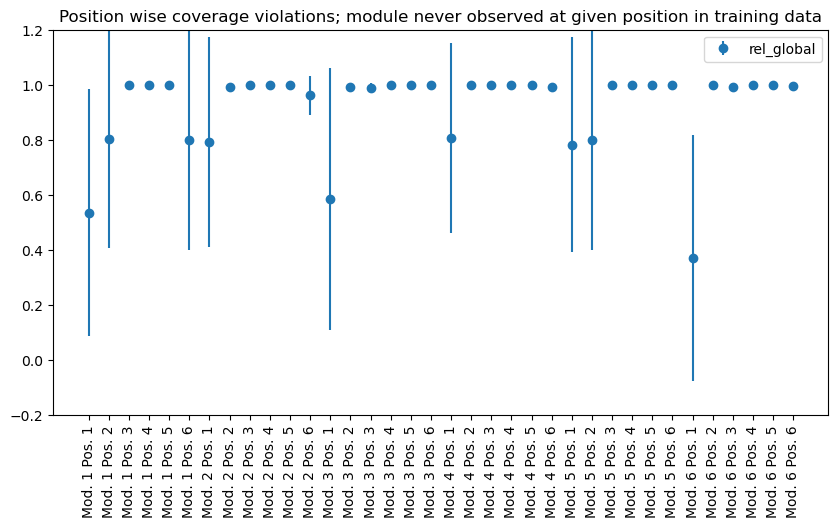

In [77]:
# find mean and std of results

import numpy as np

for pos in pos_list:
    x_values = []
    y_values = []
    y_std = []
    plt.figure(figsize=(10, 5))
    for strategy_index, strategy in enumerate(strategies):
        
        mean = np.mean(results[pos][strategy])
        # if mean < 0.9:
        module_name = int(strategy.split("_")[2]) + 1   
        pos_name = int(strategy.split("_")[3]) + 1
        x_values.append(f"Mod. {module_name} Pos. {pos_name}")
        # x_values.append(strategy)
        y_values.append(np.mean(results[pos][strategy]))
        y_std.append(np.std(results[pos][strategy]))
        
        # print(pos, strategy,b
        # results[pos][strategy])
        # print(pos, strategy, np.mean(results[pos][strategy]), np.std(results[pos][strategy]))
        # plot error bar
        # have vertical line after each 6 strategies
    #     if int(strategy.split("_")[3]) == 0 or int(strategy.split("_")[3]) == 5:
    #         plt.axvline(x=strategy_index, color='black', linestyle='--')
    # # 
    plt.errorbar(x_values, y_values, yerr=y_std, fmt='o', label=pos)
    plt.title("Position wise coverage violations; module never observed at given position in training data")
    # x-axis labels at 45 degree angle
    plt.xticks(rotation=90)
    plt.ylim(-0.2, 1.2)
    plt.legend()
    plt.show()


# Reverse position wise coverage violations



- Training data: 120 compositions
- Test data: 600 compositions

- Training compositions **always** observe a given module at a given position e.g., f1 f2 f3 f4 f5 f6, f1 f3 f4 f5 f6
- Test compositions observe remaining modules at a given position e.g., f2, f1, f3...
- **Position Coverage Divergence (KL): 6.990042**
- **Pairwise Adjacency Divergence (KL): 3.782880**
- **Combined Divergence (KL) (α=0.5): 5.386461**




In [78]:
import os
seeds = [0, 10, 20, 30, 40]
pos_list = ["abs", "rel_global"]
strategies = ["reversecoverage_6_0_0", "reversecoverage_6_0_1", "reversecoverage_6_0_2", "reversecoverage_6_0_3", "reversecoverage_6_0_4", "reversecoverage_6_0_5", 
              "reversecoverage_6_1_0", "reversecoverage_6_1_1", "reversecoverage_6_1_2", "reversecoverage_6_1_3", "reversecoverage_6_1_4", "reversecoverage_6_1_5", 
              "reversecoverage_6_2_0", "reversecoverage_6_2_1", "reversecoverage_6_2_2", "reversecoverage_6_2_3", "reversecoverage_6_2_4", "reversecoverage_6_2_5", 
              "reversecoverage_6_3_0", "reversecoverage_6_3_1", "reversecoverage_6_3_2", "reversecoverage_6_3_3", "reversecoverage_6_3_4", "reversecoverage_6_3_5", 
              "reversecoverage_6_4_0", "reversecoverage_6_4_1", "reversecoverage_6_4_2", "reversecoverage_6_4_3", "reversecoverage_6_4_4", "reversecoverage_6_4_5", 
              "reversecoverage_6_5_0", "reversecoverage_6_5_1", "reversecoverage_6_5_2", "reversecoverage_6_5_3", "reversecoverage_6_5_4", "reversecoverage_6_5_5"]

count = 0
results = {}
for pos in pos_list:
    results[pos] = {}
    for strategy in strategies:
        results[pos][strategy] = []
        for seed in seeds:
            train_strategy_name = f"train_{strategy}"
            eval_strategy_name = f"eval_{strategy}"
            results_path = f"{path}/{train_strategy_name}/{eval_strategy_name}/{pos}/nh6_nl3/seed_{seed}/accs.pkl"
            
            
            metrics = pickle.load(open(results_path, 'rb'))
            results[pos][strategy].append(metrics["test"].sharp_accuracy)
           
        
print(count)
            # else:
            #     results[pos][strategy].append(0)

            
                
                
            # else:
            #     train_strategy_name = f"train_coverage_{strategy}"
            #     eval_strategy_name = f"eval_coverage_{strategy}"
            #     results_path = f"{path}/{train_strategy_name}/{eval_strategy_name}/{pos}/nh6_nl3/seed_{seed}/accs.pkl"
            #     metrics = pickle.load(open(results_path, 'rb'))
            #     results[pos][strategy].append(metrics["test"].sharp_accuracy)


0


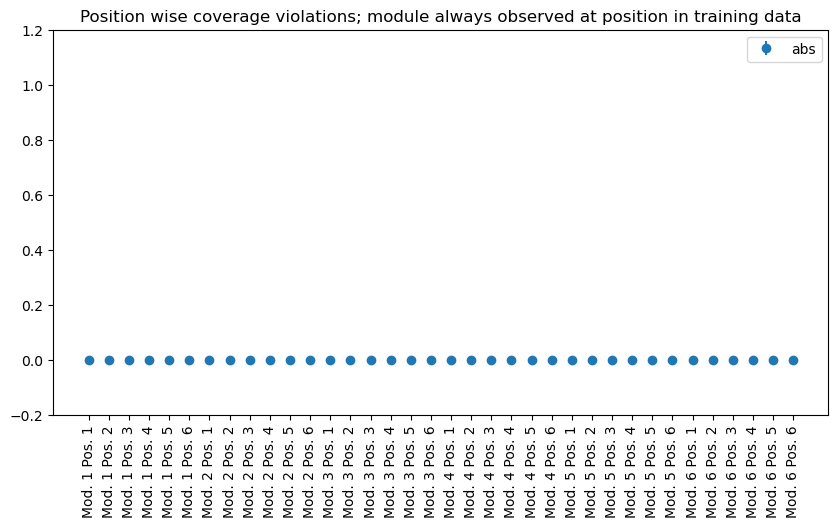

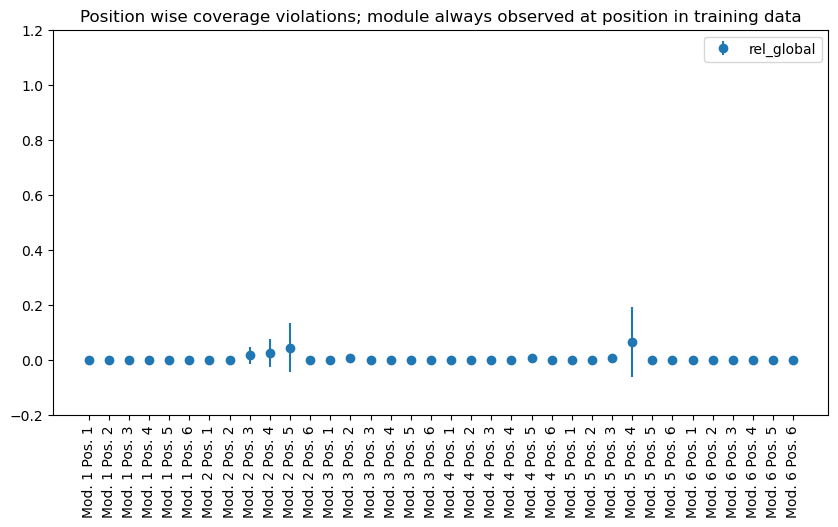

In [79]:
# find mean and std of results

import numpy as np

for pos in pos_list:
    x_values = []
    y_values = []
    y_std = []
    plt.figure(figsize=(10, 5))
    for strategy_index, strategy in enumerate(strategies):
        
        mean = np.mean(results[pos][strategy])
        # if mean < 0.9:
        module_name = int(strategy.split("_")[2]) + 1   
        pos_name = int(strategy.split("_")[3]) + 1
        x_values.append(f"Mod. {module_name} Pos. {pos_name}")
        
        y_values.append(np.mean(results[pos][strategy]))
        y_std.append(np.std(results[pos][strategy]))
        # print(pos, strategy,b
        # results[pos][strategy])
        # print(pos, strategy, np.mean(results[pos][strategy]), np.std(results[pos][strategy]))
        # plot error bar
        # have vertical line after each 6 strategies
    #     if int(strategy.split("_")[3]) == 0 or int(strategy.split("_")[3]) == 5:
    #         plt.axvline(x=strategy_index, color='black', linestyle='--')
    # # 
    plt.errorbar(x_values, y_values, yerr=y_std, fmt='o', label=pos)
    plt.title("Position wise coverage violations; module always observed at position in training data")
    # x-axis labels at 45 degree angle
    plt.xticks(rotation=90)
    plt.ylim(-0.2, 1.2)
    plt.legend()
    plt.show()


# Pair-wise coverage violations


- Training data: 600 compositions
- Test data: 120 compositions

- Training compositions **never** observe a given pair of modules across any position e.g., f1 f2 never appears 
- Test compositions **always** observe a given pair of modules across any position, all compositions have f1 f2 
- Position Coverage Divergence (KL): 0.083821
- **Pairwise Adjacency Divergence (KL): 4.461797**
- Combined Divergence (KL) (α=0.5): 2.272809



In [89]:
import os
seeds = [0, 10, 20, 30, 40]
pos_list = ["abs", "rel_global"]
nums = list(np.arange(0, 30))

strategies = [f"paircoverage_6_{i}" for i in nums ]

count = 0
results = {}
train_results = {}
train_heldout_results = {}
for pos in pos_list:
    results[pos] = {}
    train_results[pos] = {}
    train_heldout_results[pos] = {}
    for strategy in strategies:
        results[pos][strategy] = []
        train_results[pos][strategy] = []
        train_heldout_results[pos][strategy] = []
        for seed in seeds:
            train_strategy_name = f"train_{strategy}"
            eval_strategy_name = f"eval_{strategy}"
            results_path = f"{path}/{train_strategy_name}/{eval_strategy_name}/{pos}/nh6_nl3/seed_{seed}/accs.pkl"
            model_path_dir = f"{MODEL_DIR}/{train_strategy_name}/{pos}/nh6_nl3/seed_{seed}"
            # find file with .pt extension
            model_fname = [f for f in os.listdir(model_path_dir) if f.endswith('.pt')][0]
            model_path = f"{model_path_dir}/{model_fname}"
            # find file info when it was created
            file_info = os.stat(results_path)
            # get readable date and time
            date_time = datetime.datetime.fromtimestamp(file_info.st_mtime).strftime('%Y-%m-%d %H:%M:%S')
            # print file info
            print(date_time)

            try:
                metrics = pickle.load(open(results_path, 'rb'))
                results[pos][strategy].append(metrics["test"].sharp_accuracy)
                
                # print("Train accuracy: ", metrics["train"].sharp_accuracy)
                # print("Train heldout accuracy: ", metrics["train_heldout"].sharp_accuracy)
                # print("Test accuracy: ", metrics["test"].sharp_accuracy)
                train_results[pos][strategy].append(metrics["train"].sharp_accuracy)
                train_heldout_results[pos][strategy].append(metrics["train_heldout"].sharp_accuracy)
            except:
                count += 1
                print(f"Error loading results from {results_path}")
                results[pos][strategy].append(0)
print(count)
            

2026-01-21 21:05:54
2026-01-21 18:42:43
2026-01-21 18:41:45
2026-01-21 18:42:10
2026-01-21 18:30:38
2026-01-21 18:32:11
2026-01-21 18:32:24
2026-01-21 18:32:28
2026-01-21 18:34:05
2026-01-21 18:35:23
2026-01-21 18:37:06
2026-01-21 18:39:02
2026-01-21 18:37:39
2026-01-21 18:38:34
2026-01-21 18:38:10
2026-01-21 18:40:14
2026-01-21 18:39:03
2026-01-21 18:39:07
2026-01-21 18:39:07
2026-01-21 18:38:54
2026-01-21 18:39:48
2026-01-20 16:52:16
2026-01-21 18:39:39
2026-01-21 18:39:49
2026-01-21 18:39:41
2026-01-21 18:40:38
2026-01-21 18:40:14
2026-01-21 18:40:27
2026-01-21 18:40:26
2026-01-21 18:40:26
2026-01-21 18:42:18
2026-01-21 18:41:54
2026-01-21 18:40:43
2026-01-21 18:40:44
2026-01-21 18:40:59
2026-01-21 18:40:59
2026-01-21 18:42:44
2026-01-21 18:42:45
2026-01-21 18:42:42
2026-01-21 18:42:35
2026-01-21 18:41:49
2026-01-21 18:41:23
2026-01-21 18:41:24
2026-01-21 18:41:23
2026-01-20 16:56:06
2026-01-21 18:43:46
2026-01-21 18:42:24
2026-01-21 18:42:37
2026-01-21 18:42:09
2026-01-21 18:31:28


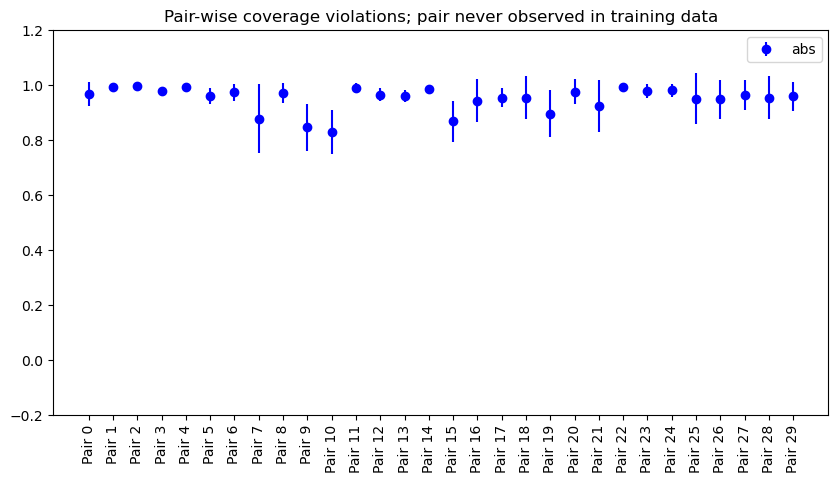

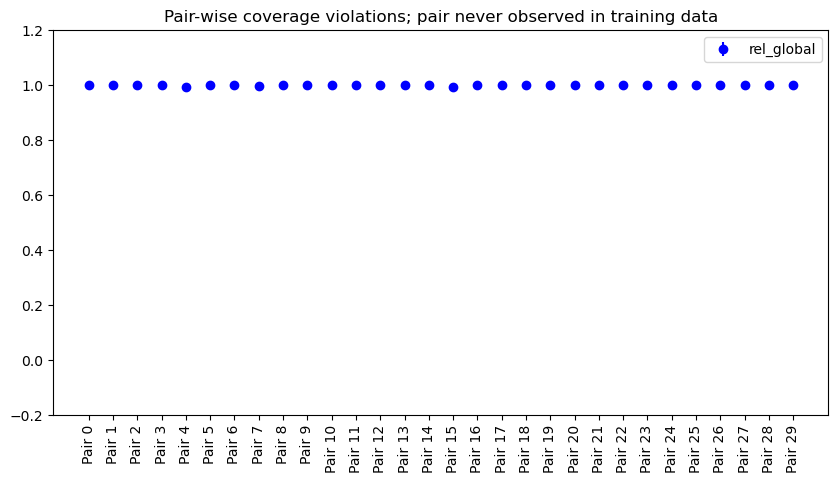

In [90]:
# find mean and std of results

import numpy as np

for pos in pos_list:
    x_values = []
    y_values = []
    y_std = []
    
    x_train_heldout = []
    y_train_heldout = []
    y_train_heldout_std = []
    plt.figure(figsize=(10, 5))
    for strategy_index, strategy in enumerate(strategies):
        
        mean = np.mean(results[pos][strategy])
        # if mean < 0.9:
        pair_number = int(strategy.split("_")[2])
        x_values.append(f"Pair {pair_number}")
        y_values.append(np.mean(results[pos][strategy]))
        y_std.append(np.std(results[pos][strategy]))

        
       
       
    plt.errorbar(x_values, y_values, yerr=y_std, fmt='o', label=pos, color='blue')
    # plt.errorbar(x_train_heldout, y_train_heldout, yerr=y_train_heldout_std, fmt='o', label=pos, color='red')
    # x-axis labels at 45 degree angle
    plt.ylim(-0.2, 1.2)
    plt.xticks(rotation=90)
    plt.title("Pair-wise coverage violations; pair never observed in training data")
    plt.legend()
    plt.show()


# Reverse pair-wise coverage violations


- Training data: 120 compositions
- Test data: 600 compositions

- Training compositions **always** observe a given pair of modules across any position, all compositions have f1 f2 
- Test compositions **never** observe a given pair of modules across any position, all compositions have f1 f2 
- Position Coverage Divergence (KL): 1.377393
- **Pairwise Adjacency Divergence (KL): 6.987699**
- Combined Divergence (KL) (α=0.5): 4.182546



In [82]:
import os
seeds = [0, 10, 20, 30, 40]
pos_list = ["abs", "rel_global"]
nums = list(np.arange(0, 30))

strategies = [f"reversepaircoverage_6_{i}" for i in nums ]

count = 0
results = {}
train_results = {}
train_heldout_results = {}
for pos in pos_list:
    results[pos] = {}
    train_results[pos] = {}
    train_heldout_results[pos] = {}
    for strategy in strategies:
        results[pos][strategy] = []
        train_results[pos][strategy] = []
        train_heldout_results[pos][strategy] = []
        for seed in seeds:
            train_strategy_name = f"train_{strategy}"
            eval_strategy_name = f"eval_{strategy}"
            results_path = f"{path}/{train_strategy_name}/{eval_strategy_name}/{pos}/nh6_nl3/seed_{seed}/accs.pkl"
            # print file info
            try:
                metrics = pickle.load(open(results_path, 'rb'))
                results[pos][strategy].append(metrics["test"].sharp_accuracy)
                
                
                train_results[pos][strategy].append(metrics["train"].sharp_accuracy)
                train_heldout_results[pos][strategy].append(metrics["train_heldout"].sharp_accuracy)
            except:
                count += 1
                print(f"Error loading results from {results_path}")
                results[pos][strategy].append(0)
print(count)
            # else:
            #     results[pos][strategy].append(0)

            
                
                
            # else:
            #     train_strategy_name = f"train_coverage_{strategy}"
            #     eval_strategy_name = f"eval_coverage_{strategy}"
            #     results_path = f"{path}/{train_strategy_name}/{eval_strategy_name}/{pos}/nh6_nl3/seed_{seed}/accs.pkl"
            #     metrics = pickle.load(open(results_path, 'rb'))
            #     results[pos][strategy].append(metrics["test"].sharp_accuracy)


0


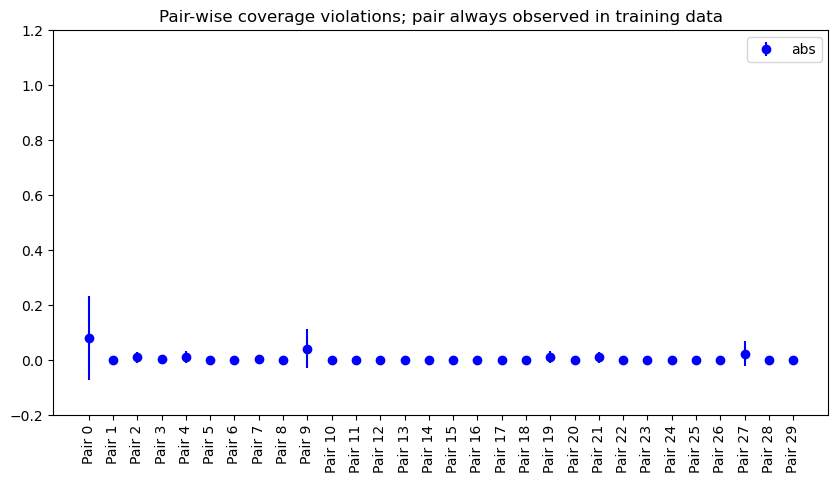

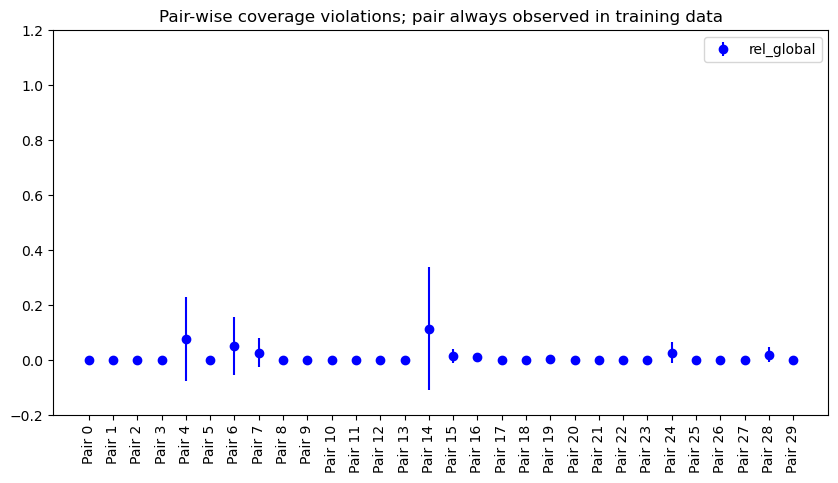

In [83]:
# find mean and std of results

import numpy as np

for pos in pos_list:
    x_values = []
    y_values = []
    y_std = []
    
    x_train_heldout = []
    y_train_heldout = []
    y_train_heldout_std = []
    plt.figure(figsize=(10, 5))
    for strategy_index, strategy in enumerate(strategies):
        
        mean = np.mean(results[pos][strategy])
        # if mean < 0.9:
        pair_number = int(strategy.split("_")[2])
        x_values.append(f"Pair {pair_number}")
        y_values.append(np.mean(results[pos][strategy]))
        y_std.append(np.std(results[pos][strategy]))
      
    plt.errorbar(x_values, y_values, yerr=y_std, fmt='o', label=pos, color='blue')
    plt.title("Pair-wise coverage violations; pair always observed in training data")
    plt.ylim(-0.2, 1.2)
    # x-axis labels at 45 degree angle
    plt.xticks(rotation=90)
    plt.legend()
    plt.show()
